# Логистическая регрессия: диагностика рака молочной железы


## Датасет

Используем `sklearn.datasets.load_breast_cancer`: 30 числовых признаков, измеренных на биоптатах, и целевая переменная с двумя классами — `0` (malignant, злокачественная опухоль) и `1` (benign, доброкачественная).


In [26]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
import matplotlib.pyplot as plt

RANDOM_STATE = 42


## Загрузка и разбиение данных

Разобьём выборку на обучающую и тестовую части, чтобы честно оценивать качество модели.


In [27]:
X, y = load_breast_cancer(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((455, 30), (114, 30), (455,), (114,))

## Первичный анализ признаков

Посмотрим на основные статистики, чтобы понять масштабы и разброс признаков.


In [28]:
feature_summary = (
    X_train.describe()
    .T[['mean', 'std', 'min', 'max']]
    .rename(columns={"mean": "Mean", "std": "Std", "min": "Min", "max": "Max"})
    .round(2)
)
feature_summary


,Mean,Std,Min,Max
mean radius,14.07,3.50,6.98,28.11
mean texture,19.25,4.41,9.71,39.28
mean perimeter,91.56,24.15,43.79,188.50
mean area,648.54,344.94,143.50,2499.00
mean smoothness,0.10,0.01,0.06,0.14
mean compactness,0.10,0.05,0.02,0.35
mean concavity,0.09,0.08,0.00,0.43
mean concave points,0.05,0.04,0.00,0.20
mean symmetry,0.18,0.03,0.11,0.30
mean fractal dimension,0.06,0.01,0.05,0.10


Статистики показывают, что признаки измеряются в разных шкалах и имеют сильно отличающиеся диапазоны. Поэтому перед обучением полезно масштабировать данные, чтобы коэффициенты и градиенты модели были устойчивыми.


In [29]:
correlation = X_train.corrwith(y_train).sort_values(ascending=False)
correlation


smoothness error           0.070507
texture error              0.023917
mean fractal dimension    -0.001027
symmetry error            -0.012765
fractal dimension error   -0.059216
concavity error           -0.252785
compactness error         -0.291239
worst fractal dimension   -0.327308
mean symmetry             -0.358370
mean smoothness           -0.392200
mean texture              -0.409384
concave points error      -0.418560
worst smoothness          -0.429227
worst symmetry            -0.430422
worst texture             -0.450765
perimeter error           -0.551905
radius error              -0.565074
area error                -0.567197
worst compactness         -0.602331
mean compactness          -0.610722
worst concavity           -0.668368
mean concavity            -0.692052
mean area                 -0.713409
mean radius               -0.732224
worst area                -0.737965
mean perimeter            -0.745132
worst radius              -0.776390
mean concave points       -0

Корреляции дают первое приближение влияния признаков: положительные значения усиливают вероятность класса `1` (benign), отрицательные — класса `0` (malignant).


## Баланс классов

Проанализируем распределение целевой переменной, чтобы понять, сталкиваемся ли мы с дисбалансом.


In [30]:
class_balance = pd.DataFrame({
    "count": y_train.value_counts().sort_index(),
    "share": y_train.value_counts(normalize=True).sort_index() * 100
}).rename(index={0: "malignant", 1: "benign"})
class_balance["share"] = class_balance["share"].round(2)
class_balance


,count,share
target,,
malignant,170,37.36
benign,285,62.64


Доли классов близки к 60/40 в пользу доброкачественных опухолей. Это не экстремальный дисбаланс, но важно следить за качеством распознавания меньшего класса `malignant`, поскольку пропуск злокачественного случая критичен.


## Обучение логистической регрессии

Используем пайплайн со стандартизацией признаков и `LogisticRegression`.


In [31]:
pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_proba_malignant = pipe.predict_proba(X_test)[:, 0]  # вероятность класса 'malignant'


## Ключевые метрики

Соберём значения точности, полноты, точности (precision) и F1 по классу `malignant`, а также ROC-AUC.


In [32]:
y_test_malignant = (y_test == 0).astype(int)
y_pred_malignant = (y_pred == 0).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test_malignant, y_pred_malignant)
rec = recall_score(y_test_malignant, y_pred_malignant)
f1 = f1_score(y_test_malignant, y_pred_malignant)
auc = roc_auc_score(y_test_malignant, y_proba_malignant)

print(f"Accuracy: {acc:.3f}")
print(f"Precision (malignant): {prec:.3f}")
print(f"Recall (malignant): {rec:.3f}")
print(f"F1-score (malignant): {f1:.3f}")
print(f"ROC-AUC (malignant): {auc:.3f}")


Accuracy: 0.982
Precision (malignant): 0.976
Recall (malignant): 0.976
F1-score (malignant): 0.976
ROC-AUC (malignant): 0.995


In [33]:
print(classification_report(y_test, y_pred, target_names=["malignant", "benign"]))


              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



Мы рассматриваем `malignant` как положительный класс, поэтому **recall** показывает долю найденных злокачественных опухолей, а **precision** — насколько редко модель ошибочно объявляет опухоль злокачественной. **F1-score** балансирует эти два показателя, а высокая точность (accuracy) подтверждает, что общая доля верных ответов велика. Значение **ROC-AUC** близкое к 1 демонстрирует хорошее разделение классов по вероятностям.


## Интерпретация коэффициентов

Логистическая регрессия предоставляет коэффициенты при стандартизированных признаках. Для удобства выделим вклад признаков в вероятность злокачественности.


In [34]:
clf = pipe.named_steps["clf"]
scaler = pipe.named_steps["scaler"]
coefficients = clf.coef_[0]
coef_df = (
    pd.DataFrame({
        "feature": X.columns,
        "coef_benign": coefficients,
        "coef_malignant": -coefficients,
    })
    .assign(abs_coef=lambda df: df["coef_malignant"].abs())
    .sort_values("abs_coef", ascending=False)
)
coef_df.head(10)


,feature,coef_benign,coef_malignant,abs_coef
21,worst texture,-1.255088,1.255088,1.255088
10,radius error,-1.082965,1.082965,1.082965
27,worst concave points,-0.953686,0.953686,0.953686
23,worst area,-0.947756,0.947756,0.947756
20,worst radius,-0.947616,0.947616,0.947616
28,worst symmetry,-0.939181,0.939181,0.939181
13,area error,-0.929104,0.929104,0.929104
26,worst concavity,-0.823151,0.823151,0.823151
22,worst perimeter,-0.763220,0.763220,0.763220
24,worst smoothness,-0.746625,0.746625,0.746625


В таблице топ-10 признаков по модулю коэффициента. Положительные значения в колонке `coef_malignant` означают рост вероятности злокачественной опухоли при увеличении признака (при прочих равных), отрицательные — смещение в сторону доброкачественных случаев.


## Матрица ошибок

Посмотрим, какие типы ошибок встречаются чаще всего.


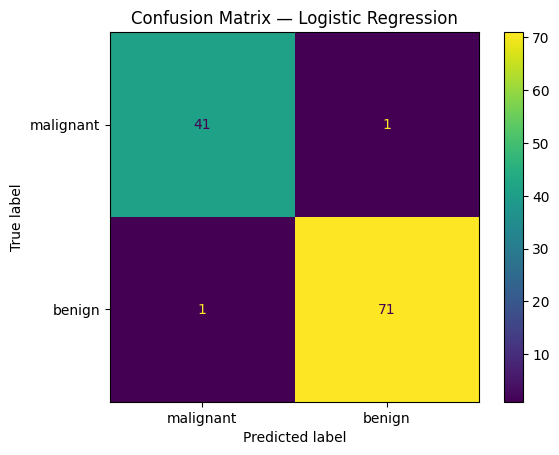

In [35]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["malignant", "benign"])
disp.plot(values_format='d')
plt.title("Confusion Matrix — Logistic Regression")
plt.show()


Верхняя правая ячейка (malignant → benign) отражает ложные отрицания — их немного, что важно для клинического применения. Нижняя левая ячейка (benign → malignant) показывает ложные тревоги, и их тоже немного, поэтому пациенты не будут массово отправляться на лишние обследования.


## ROC-кривая

Оценим качество ранжирования по вероятностям.


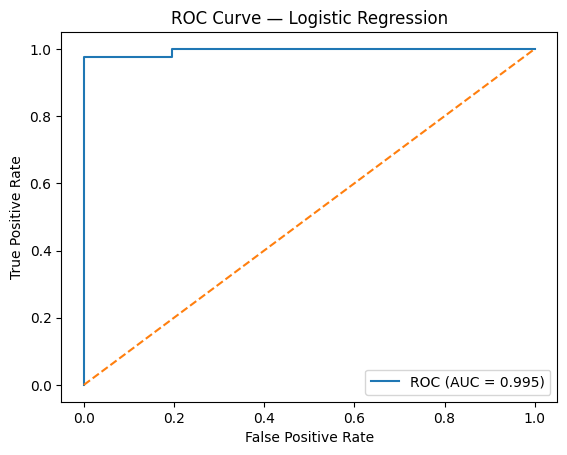

In [36]:
fpr, tpr, thr = roc_curve(y_test_malignant, y_proba_malignant)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression")
plt.legend()
plt.show()


Кривая заметно выше диагонали, а площадь под ней близка к единице — модель способна отделять злокачественные случаи от доброкачественных при разных порогах классификации, что позволяет выбирать компромисс между чувствительностью и специфичностью.
